# 05 — Validation
Full validation suite on OOT for both models. Mirrors what a bank's model risk team would run.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import lightgbm as lgb
from pathlib import Path
from sklearn.metrics import roc_auc_score, roc_curve

PROC = Path('../Data/Processed')
OUT  = Path('../Outputs')

df = pd.read_parquet(PROC / 'master_features.parquet').sort_values('SK_ID_CURR')

with open(PROC / 'selected_features.json') as f:
    selected_features = json.load(f)

# same 80/20 split as NB03 and NB04
split = int(len(df) * 0.8)
train = df.iloc[:split]
oot   = df.iloc[split:]

# load both trained models
lr      = joblib.load(OUT / 'lr_model.pkl')
binning = joblib.load(OUT / 'binning.pkl')
lgb_m   = lgb.Booster(model_file=str(OUT / 'lgbm_model.txt'))

# scorecard predictions — WoE transform first
X_train_woe = binning.transform(train[selected_features], metric='woe')
X_oot_woe   = binning.transform(oot[selected_features],   metric='woe')
y_pred_lr       = lr.predict_proba(X_oot_woe)[:, 1]
y_pred_lr_train = lr.predict_proba(X_train_woe)[:, 1]

# LightGBM predictions — cast object columns to category
def prepare_lgb(data):
    out = data[selected_features].copy()
    for col in selected_features:
        if out[col].dtype == 'object':
            out[col] = out[col].astype('category')
    return out

y_pred_lgb = lgb_m.predict(prepare_lgb(oot))
y_true     = oot['TARGET'].values

print(f"OOT size: {len(y_true):,} | Default rate: {y_true.mean():.2%}")

OOT size: 61,503 | Default rate: 7.94%


## 1. Discrimination — Gini, KS, AUC

Model                     |      AUC |     Gini |       KS
---------------------------------------------------------
WoE Scorecard             | AUC 0.7580 | Gini 0.5160 | KS 0.3914
LightGBM                  | AUC 0.7725 | Gini 0.5451 | KS 0.4090


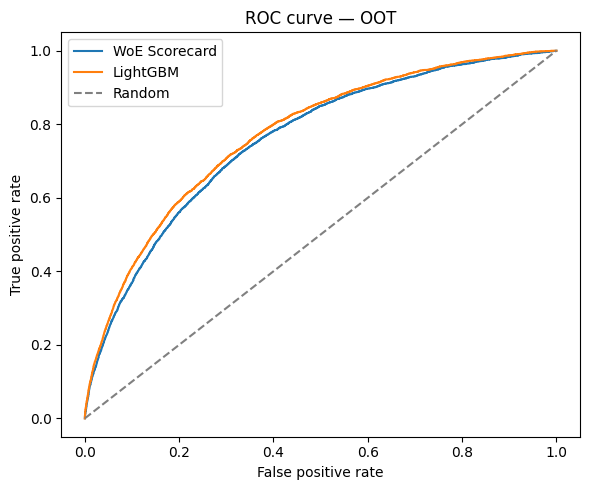

In [2]:
def discrimination_metrics(y_true, y_pred, label):
    auc  = roc_auc_score(y_true, y_pred)
    gini = 2 * auc - 1
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    ks   = (tpr - fpr).max()
    print(f"{label:25s} | AUC {auc:.4f} | Gini {gini:.4f} | KS {ks:.4f}")
    return fpr, tpr

print(f"{'Model':25s} | {'AUC':>8} | {'Gini':>8} | {'KS':>8}")
print("-" * 57)
fpr_lr,  tpr_lr  = discrimination_metrics(y_true, y_pred_lr,  'WoE Scorecard')
fpr_lgb, tpr_lgb = discrimination_metrics(y_true, y_pred_lgb, 'LightGBM')

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_lr,  tpr_lr,  label='WoE Scorecard')
ax.plot(fpr_lgb, tpr_lgb, label='LightGBM')
ax.plot([0, 1], [0, 1], '--', color='grey', label='Random')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curve — OOT')
ax.legend()
plt.tight_layout()
plt.savefig(OUT / 'roc_curve.png', dpi=100)
plt.show()

## 2. Calibration — Hosmer-Lemeshow decile table

In [3]:
hl = pd.DataFrame({'y': y_true, 'pd': y_pred_lr})
hl['decile'] = pd.qcut(hl['pd'], q=10, labels=False, duplicates='drop')

hl_table = hl.groupby('decile').agg(
    n        = ('y', 'count'),
    observed = ('y', 'sum'),
    avg_pd   = ('pd', 'mean'),
)
hl_table['expected'] = hl_table['n'] * hl_table['avg_pd']
hl_table['obs_rate'] = hl_table['observed'] / hl_table['n']
print(hl_table.round(4).to_string())

           n  observed  avg_pd   expected  obs_rate
decile                                             
0       6151        91  0.0128    78.4931    0.0148
1       6150       104  0.0217   133.3463    0.0169
2       6150       173  0.0295   181.5364    0.0281
3       6150       185  0.0381   234.0782    0.0301
4       6151       276  0.0482   296.2933    0.0449
5       6150       365  0.0612   376.3594    0.0593
6       6150       513  0.0787   483.9289    0.0834
7       6150       655  0.1040   639.5558    0.1065
8       6150       928  0.1465   900.8343    0.1509
9       6151      1594  0.2661  1637.0768    0.2591


## 3. Population Stability Index

In [4]:
def psi(expected, actual, n_bins=10):
    breaks = np.percentile(expected, np.linspace(0, 100, n_bins + 1))
    breaks[0] -= 1e-8; breaks[-1] += 1e-8
    e = np.histogram(expected, bins=breaks)[0] / len(expected)
    a = np.histogram(actual,   bins=breaks)[0] / len(actual)
    # replace zero buckets to avoid log(0)
    e = np.where(e == 0, 1e-8, e)
    a = np.where(a == 0, 1e-8, a)
    return np.sum((a - e) * np.log(a / e))

p      = psi(y_pred_lr_train, y_pred_lr)
status = 'Stable' if p < 0.10 else 'Monitor' if p < 0.25 else 'UNSTABLE'
print(f"PSI (Scorecard): {p:.4f} — {status}")

PSI (Scorecard): 0.0003 — Stable


## 4. Rank-ordering decile table

In [5]:
ro = pd.DataFrame({'y': y_true, 'pd': y_pred_lr})
# decile 10 = highest risk, decile 1 = lowest risk
ro['decile'] = pd.qcut(ro['pd'], q=10, labels=range(10, 0, -1), duplicates='drop')

decile_tbl = ro.groupby('decile', observed=True).agg(
    count        = ('y', 'count'),
    defaults     = ('y', 'sum'),
    default_rate = ('y', 'mean'),
    avg_pd       = ('pd', 'mean'),
)
decile_tbl['pct_defaults_captured'] = decile_tbl['defaults'].cumsum() / decile_tbl['defaults'].sum()
print(decile_tbl.round(4).to_string())
decile_tbl.to_csv(OUT / 'decile_table.csv')

        count  defaults  default_rate  avg_pd  pct_defaults_captured
decile                                                              
10       6151        91        0.0148  0.0128                 0.0186
9        6150       104        0.0169  0.0217                 0.0399
8        6150       173        0.0281  0.0295                 0.0753
7        6150       185        0.0301  0.0381                 0.1132
6        6151       276        0.0449  0.0482                 0.1697
5        6150       365        0.0593  0.0612                 0.2445
4        6150       513        0.0834  0.0787                 0.3495
3        6150       655        0.1065  0.1040                 0.4836
2        6150       928        0.1509  0.1465                 0.6736
1        6151      1594        0.2591  0.2661                 1.0000


## 5. Final model comparison

In [6]:
results = pd.DataFrame([
    {
        'Model':          'WoE Scorecard',
        'AUC':            round(roc_auc_score(y_true, y_pred_lr),  4),
        'Gini':           round(2 * roc_auc_score(y_true, y_pred_lr)  - 1, 4),
        'Interpretable':  'Yes',
        'Regulatory fit': 'Yes (Basel IRB)',
    },
    {
        'Model':          'LightGBM',
        'AUC':            round(roc_auc_score(y_true, y_pred_lgb), 4),
        'Gini':           round(2 * roc_auc_score(y_true, y_pred_lgb) - 1, 4),
        'Interpretable':  'Feature importance only',
        'Regulatory fit': 'No',
    },
])
print(results.to_string(index=False))
results.to_csv(OUT / 'model_comparison.csv', index=False)

        Model    AUC   Gini           Interpretable  Regulatory fit
WoE Scorecard 0.7580 0.5160                     Yes Yes (Basel IRB)
     LightGBM 0.7725 0.5451 Feature importance only              No
